In [1]:
# Imports
import gymnasium as gym
import numpy as np

 Observation space: Discrete(64)
 Action space: Discrete(4)


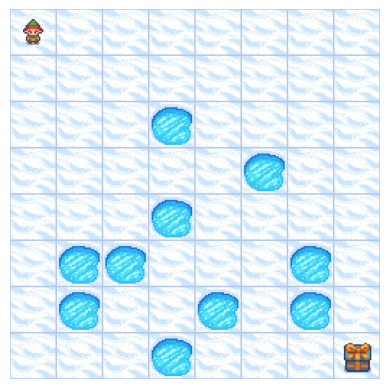

In [2]:
# Create and display the environment
frozen_lake_env = gym.make("FrozenLake-v1", map_name="8x8", render_mode="rgb_array")

print(" Observation space:", frozen_lake_env.observation_space)
print(" Action space:", frozen_lake_env.action_space)

frozen_lake_env.reset()
frame = frozen_lake_env.render()

# Display the rendered frame
import matplotlib.pyplot as plt
plt.imshow(frame)
plt.axis('off')
plt.show()

## Goal

Find the optimal Q-values for each state-action pair. 

Start by initializing $Q(s, a) = 0$ for all $s$ and $a$ 

In [3]:
def initialize_q_table(env):
    """Initialize the Q-table with zeros."""
    return np.zeros((env.observation_space.n, env.action_space.n))

## $\epsilon$ - greedy policy

A policy that selects a random action with probaility $\epsilon$ and with probaility $1 - \epsilon$ selects the action which maximizes the Q-value from a given state.

\begin{equation}
a = argmax_{a} Q(s,a)
\end{equation}

In [30]:
# frozen_lake_env.reset()

new_state, reward, terminated, truncated, _ = frozen_lake_env.step(3)

print("New state:", new_state)
print("Reward:", reward)
print("Terminated:", terminated)

New state: 0
Reward: 0.0
Terminated: False


## Q-learning algorithm

Update rule is given by

\begin{equation}
Q (S_t, A_t) \leftarrow Q(S_t, A_t) + \gamma \left( r_{t+1} + max_a Q(S_{t+1}, a) - Q(S_t, A_t) \right)
\end{equation}

In [31]:
def train(env, q_table, num_episodes=1000, max_steps_per_episode=200, learning_rate=0.1, discount_factor=0.99, max_exploration_rate=1.0, min_exploration_rate=0.5, exploration_decay_rate=0.001):
    """Train the agent using the Q-learning algorithm."""
    
    # Loop through episodes
    for episode in range(num_episodes):
        # Compute the exploration rate for this episode
        exploration_rate = min_exploration_rate + (max_exploration_rate - min_exploration_rate) * np.exp(-exploration_decay_rate * episode)

        # Reset the environment and get the initial state
        state, _ = env.reset()

        print(f"Episode {episode + 1}/{num_episodes}")
        
        # Go through each step of the episode
        for step in range(max_steps_per_episode):
            # Choose an action using epsilon-greedy strategy
            if np.random.uniform(0, 1) < exploration_rate:
                action = env.action_space.sample()  # Explore: select a random action
            else:
                action = np.argmax(q_table[state])  # Exploit: select the action with max Q-value
            
            # Take the action and observe the new state and reward
            new_state, reward, terminated, truncated, _ = env.step(action)
            
            # Update the Q-table using the Q-learning formula
            q_table[state, action] = q_table[state, action] + learning_rate * (reward + discount_factor * np.max(q_table[new_state, :]) - q_table[state, action])

            # Break the loop if the episode is done
            # TODO: What's the difference between terminated and truncated? Should we break if either is True?
            # Answer: In the context of OpenAI Gym environments, "terminated" typically indicates that the episode has ended due to a specific condition being met (e.g., reaching a goal state, falling into a hole, etc.), 
            # while "truncated" indicates that the episode has been cut off due to reaching a maximum number of steps or time limit. 
            # In most cases, you would want to break the loop if either "terminated" or "truncated" is True, as both conditions signify the end of an episode.
            if terminated or truncated:
                break

            # Update the state
            state = new_state
    
    return q_table

In [32]:
## Train the agent using the Q-learning algorithm
num_episodes = 100
max_steps_per_episode = 500
learning_rate = 0.1
discount_factor = 0.99
max_exploration_rate = 1.0
min_exploration_rate = 0.5
exploration_decay_rate = 0.001

q_table = initialize_q_table(frozen_lake_env)
trained_q_table = train(frozen_lake_env, q_table, num_episodes, max_steps_per_episode, learning_rate, discount_factor, max_exploration_rate, min_exploration_rate, exploration_decay_rate)

print("Trained Q-table shape:", trained_q_table.shape)

Episode 1/100
Episode 2/100
Episode 3/100
Episode 4/100
Episode 5/100
Episode 6/100
Episode 7/100
Episode 8/100
Episode 9/100
Episode 10/100
Episode 11/100
Episode 12/100
Episode 13/100
Episode 14/100
Episode 15/100
Episode 16/100
Episode 17/100
Episode 18/100
Episode 19/100
Episode 20/100
Episode 21/100
Episode 22/100
Episode 23/100
Episode 24/100
Episode 25/100
Episode 26/100
Episode 27/100
Episode 28/100
Episode 29/100
Episode 30/100
Episode 31/100
Episode 32/100
Episode 33/100
Episode 34/100
Episode 35/100
Episode 36/100
Episode 37/100
Episode 38/100
Episode 39/100
Episode 40/100
Episode 41/100
Episode 42/100
Episode 43/100
Episode 44/100
Episode 45/100
Episode 46/100
Episode 47/100
Episode 48/100
Episode 49/100
Episode 50/100
Episode 51/100
Episode 52/100
Episode 53/100
Episode 54/100
Episode 55/100
Episode 56/100
Episode 57/100
Episode 58/100
Episode 59/100
Episode 60/100
Episode 61/100
Episode 62/100
Episode 63/100
Episode 64/100
Episode 65/100
Episode 66/100
Episode 67/100
Epis

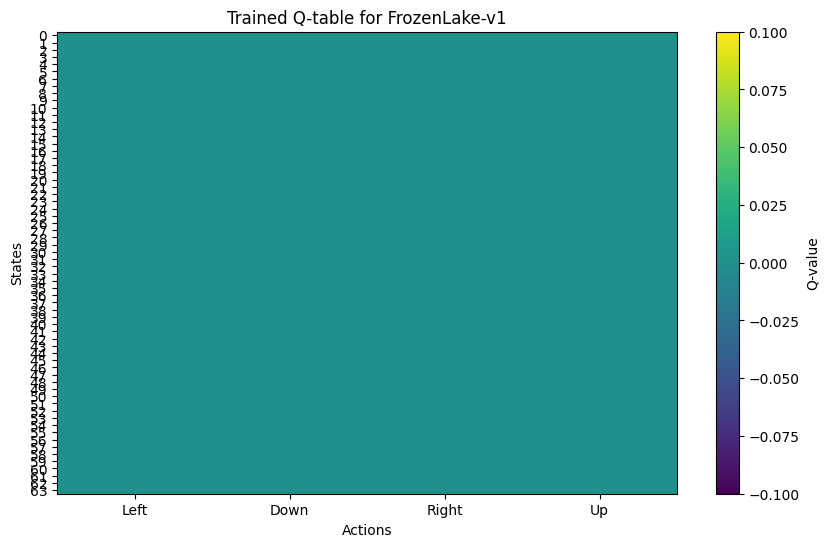

In [33]:
# Visualize the trained Q-table
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.imshow(trained_q_table, cmap='viridis', aspect='auto')
plt.colorbar(label='Q-value')
plt.title('Trained Q-table for FrozenLake-v1')
plt.xlabel('Actions')
plt.ylabel('States')
plt.xticks(ticks=np.arange(frozen_lake_env.action_space.n), labels=['Left', 'Down', 'Right', 'Up'])
plt.yticks(ticks=np.arange(frozen_lake_env.observation_space.n))
plt.show()  